In [7]:
import pandas as pd 

In [12]:
df = df = pd.read_csv("C:/Users/peter/Downloads/archive/Sample - Superstore.csv", encoding="latin1")
df.head() 


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [13]:
df.info () 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"]) 

In [16]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [17]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name() 

In [18]:
monthly_sales = df.groupby("Month Name")["Sales"].sum()

monthly_sales

Month Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='Month'>

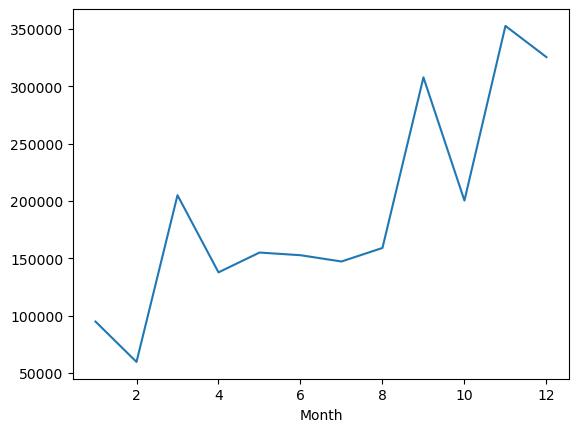

In [19]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales.sort_index().plot() 

<Axes: xlabel='Discount', ylabel='Profit'>

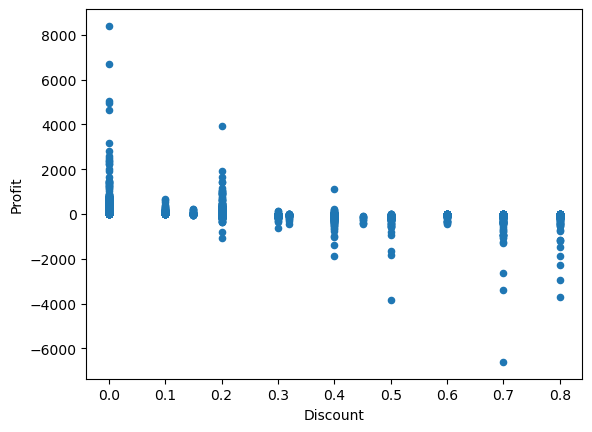

In [20]:
df.plot.scatter(x="Discount", y="Profit") 

<Axes: xlabel='Region'>

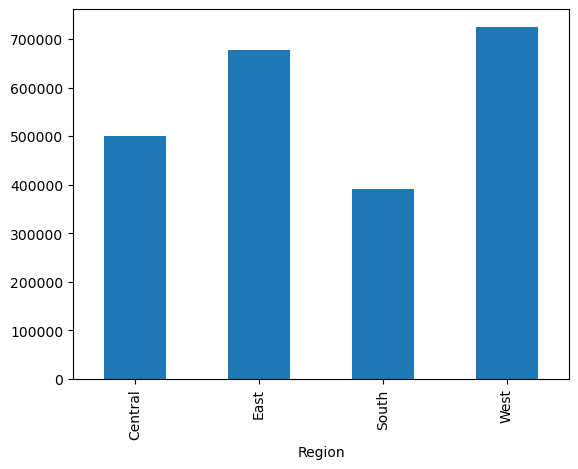

In [21]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")

In [22]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [23]:
df["Profit Margin"] = df["Profit"] / df["Sales"]

df.groupby("Category")[["Sales", "Profit", "Profit Margin"]].mean() 

,Sales,Profit,Profit Margin
Category,,,
Furniture,349.834887,8.699327,0.038784
Office Supplies,119.324101,20.327050,0.138030
Technology,452.709276,78.752002,0.156138


In [24]:
loss_df = df[df["Profit"] < 0]

loss_df.groupby("Category")["Profit"].sum()

Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64

In [25]:
df.groupby("Discount")[["Sales", "Profit"]].mean()

,Sales,Profit
Discount,,
0.00,226.742074,66.900292
0.10,578.397351,96.055074
0.15,529.971567,27.288298
0.20,209.076940,24.702572
0.30,454.742974,-45.679636
0.32,536.794770,-88.560656
0.40,565.134874,-111.927429
0.45,498.634000,-226.646464
0.50,892.705152,-310.703456


In [26]:
df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

In [27]:
df.groupby("Segment")[["Sales", "Profit"]].sum()

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [29]:
customer_sales = df.groupby("Customer Name")["Sales"].sum()

top_customers = customer_sales.sort_values(ascending=False).head(10)
low_customers = customer_sales.sort_values().head(10) 

In [30]:
df.groupby("Year")["Sales"].sum().pct_change()

Year
2014         NaN
2015   -0.028322
2016    0.294715
2017    0.203560
Name: Sales, dtype: float64

In [31]:
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

df.groupby("Ship Mode")["Shipping Time"].mean()

Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Shipping Time, dtype: float64

In [32]:
df.groupby("State")["Profit"].sum().sort_values()

State
Texas                  -25729.3563
Ohio                   -16971.3766
Pennsylvania           -15559.9603
Illinois               -12607.8870
North Carolina          -7490.9122
Colorado                -6527.8579
Tennessee               -5341.6936
Arizona                 -3427.9246
Florida                 -3399.3017
Oregon                  -1190.4705
Wyoming                   100.1960
West Virginia             185.9216
North Dakota              230.1497
South Dakota              394.8283
Maine                     454.4862
Idaho                     826.7231
Kansas                    836.4435
District of Columbia     1059.5893
New Mexico               1157.1161
Iowa                     1183.8119
New Hampshire            1706.5028
South Carolina           1769.0566
Montana                  1833.3285
Nebraska                 2037.0942
Louisiana                2196.1023
Vermont                  2244.9783
Utah                     2546.5335
Mississippi              3172.9762
Nevada        

In [33]:
df[["Sales", "Profit", "Discount", "Quantity"]].corr()

,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


In [34]:
pd.pivot_table(
    df,
    values="Profit",
    index="Category",
    columns="Region",
    aggfunc="sum"
)

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


<Axes: xlabel='Order Date'>

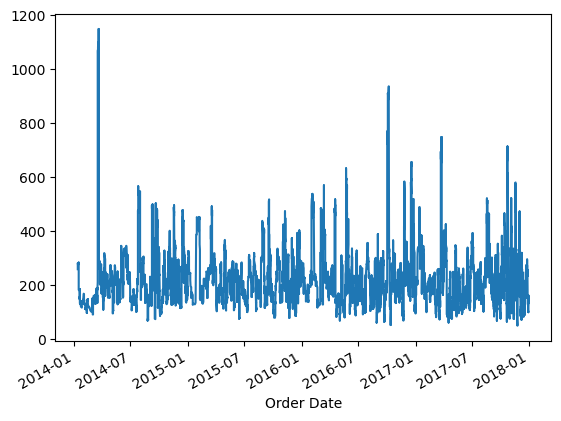

In [35]:
df_sorted = df.sort_values("Order Date")

df_sorted.set_index("Order Date")["Sales"].rolling(30).mean().plot()

In [36]:
superstore-analysis/
│
├── data/
├── notebook/
├── visuals/
├── README.md

SyntaxError: invalid character '│' (U+2502) (206366730.py, line 2)

In [37]:
import pandas as pd

df = pd.read_csv("C:/Users/peter/Downloads/archive/Sample - Superstore.csv", encoding="latin1")

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create new features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


In [38]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Orders:", df["Order ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009


<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

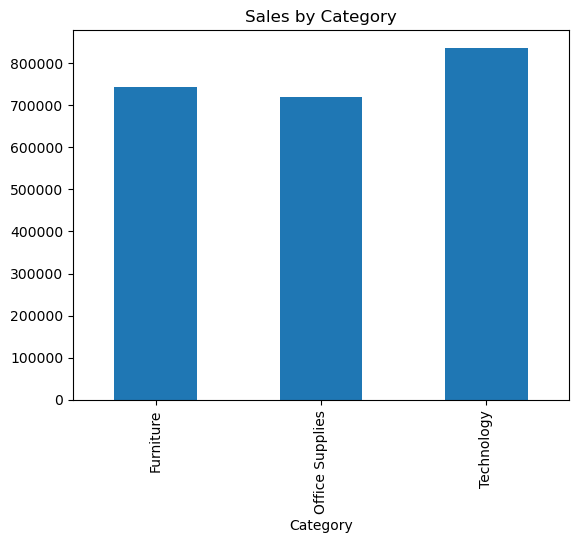

In [39]:
df.groupby("Category")["Sales"].sum().plot(kind="bar", title="Sales by Category")

<Axes: title={'center': 'Profit by Category'}, xlabel='Category'>

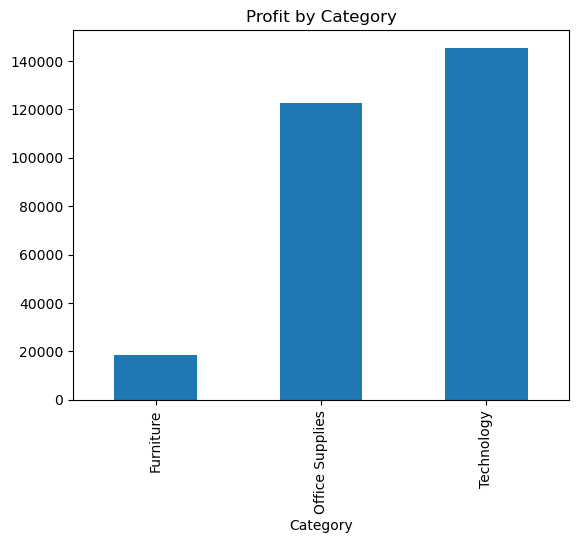

In [40]:
df.groupby("Category")["Profit"].sum().plot(kind="bar", title="Profit by Category")

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

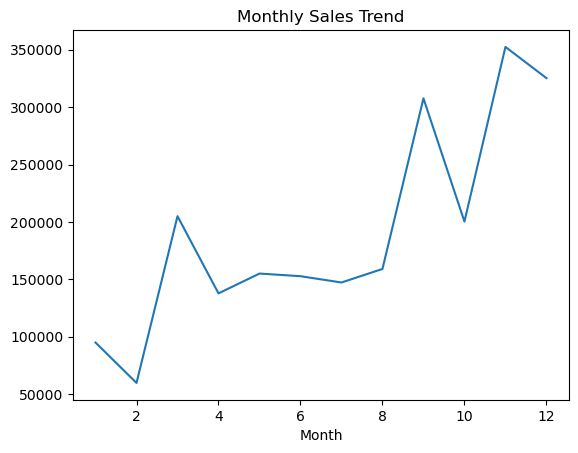

In [41]:
df.groupby("Month")["Sales"].sum().plot(title="Monthly Sales Trend")

<Axes: title={'center': 'Sales by Region'}, xlabel='Region'>

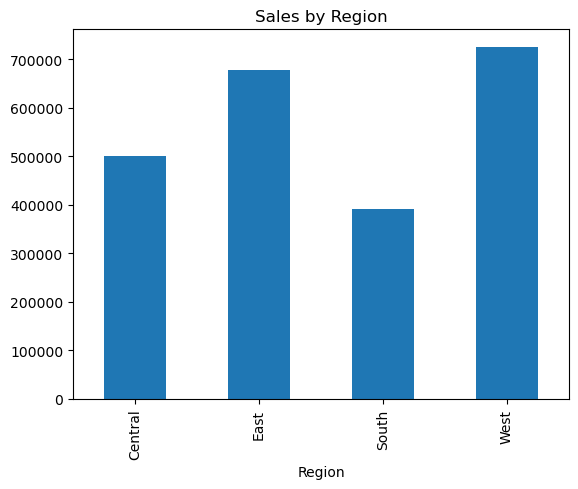

In [42]:
df.groupby("Region")["Sales"].sum().plot(kind="bar", title="Sales by Region")

<Axes: title={'center': 'Discount vs Profit'}, xlabel='Discount', ylabel='Profit'>

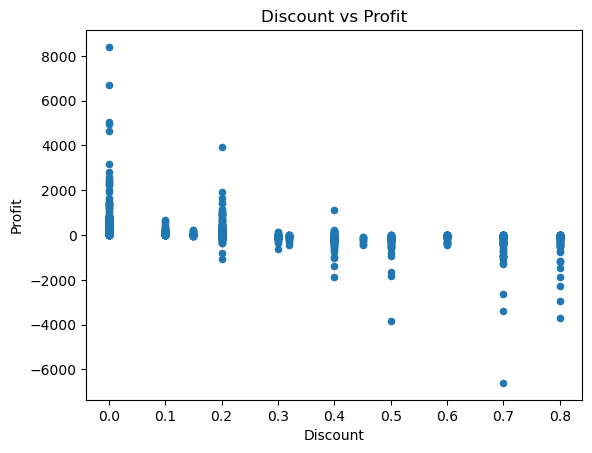

In [43]:
df.plot.scatter(x="Discount", y="Profit", title="Discount vs Profit")

FileNotFoundError: [Errno 2] No such file or directory: 'visuals/sales_by_category.png'

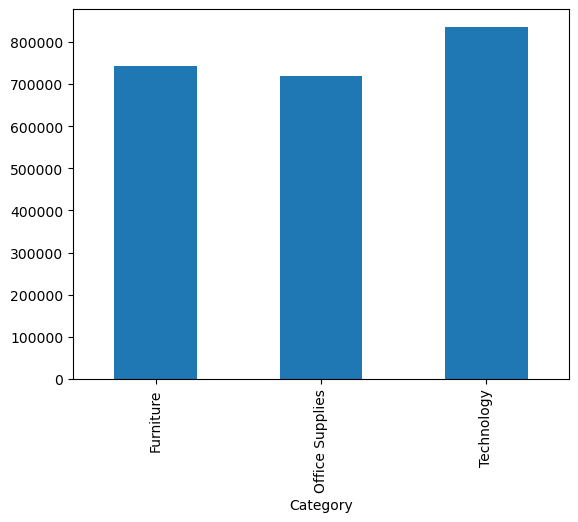

In [44]:
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.savefig("visuals/sales_by_category.png")

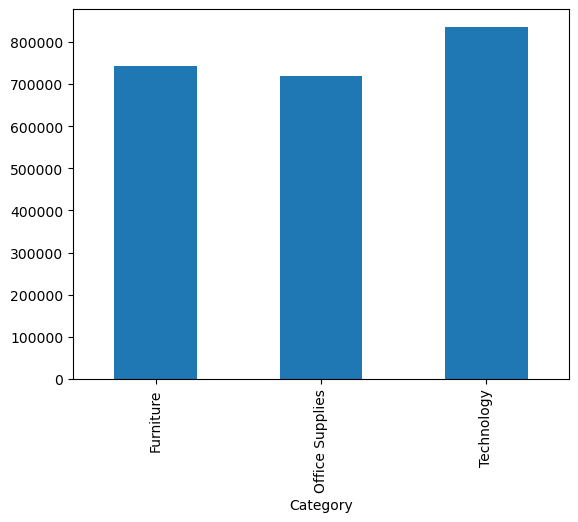

In [45]:
import os

os.makedirs("visuals", exist_ok=True)

df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.savefig("visuals/sales_by_category.png")

In [47]:
plt.savefig("sales_by_category.png")

<Figure size 640x480 with 0 Axes>

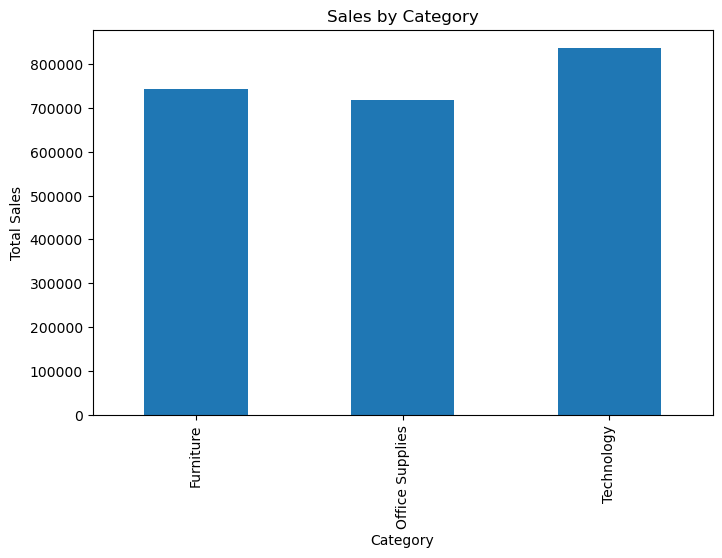

In [48]:
plt.figure(figsize=(8,5))
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

os.makedirs("visuals", exist_ok=True)
plt.savefig("visuals/sales_by_category.png")
plt.show() 

In [49]:
df.groupby("Sub-Category")["Profit"].sum().sort_values().head(5) 

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

In [50]:
df.groupby("Segment")["Profit"].sum() 

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [51]:
df.groupby("State")["Profit"].sum().sort_values().head() 

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Name: Profit, dtype: float64

In [52]:
df[df["Discount"] > 0.3]["Profit"].mean()

np.float64(-107.20993018867925)

In [9]:
import os
print(os.getcwd())

C:\Users\peter


In [17]:
df = pd.read_csv(r"C:\Users\peter\OneDrive\Desktop\superstore-analysis\data\Sample - Superstore.csv", encoding="latin1")

In [18]:
df = pd.read_csv(r"C:\Users\peter\OneDrive\Desktop\superstore-analysis\data\Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
